In [206]:
import jax
import jax.numpy as jnp

import numpy as np

import matplotlib.pyplot as plt

from toolbox import *

import qutip as qt

## Relaxation

In [207]:
def liouv_relax_channel(c):
    l = tensor(c, c.conj())
    l -= 1 / 2 * tensor(hconj(c) @ c, identity(len(c)))
    l -= 1 / 2 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return l

In [208]:
def eval_idling_matrix(cs, t):
    l = sum(liouv_relax_channel(c) for c in cs)
    return jsp.linalg.expm(l * t)

In [209]:
def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    get_t_phi_qub = lambda t1, t2: 1 / ((1 / t2) - (1 / t1) / 2)
    t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

    sigm = tensor(sigma.m, identity(N_cav))
    sigz = tensor(sigma.z, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))
    
    c_ops = [
        1 / jnp.sqrt(t1_qub) * sigm,
        1 / jnp.sqrt(t_phi_qub) * sigz / jnp.sqrt(2),
        1 / jnp.sqrt(t1_cav) * a
    ]
    return c_ops

In [210]:
def make_idle(N_cav, t1_qub, t2_qub, t1_cav, t):
    cs = build_c_ops(N_cav, t1_qub, t2_qub, t1_cav)
    idling_matrix = eval_idling_matrix(cs, t)

    def idle(rho):
        rho_liouv = rho.reshape(-1, 1)
        rho_liouv = idling_matrix @ rho_liouv
        return rho_liouv.reshape(rho.shape)

    return idle

## Solver without relaxation

In [211]:
N_cav = 31
chi =  0.6641440162100237 * (2 * jnp.pi)

In [212]:
mu_qub = 1
mu_cav = 1


def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a
    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    H_drift = +(chi / 2) * n_phot @ (sigz + one)
    
    ht = [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],
        [mu_cav * adag, e_cav, 1, 1]
    ]
    return ht


def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    hmat = hmat_from_htree(htree)
    return evol_hdt_exp(hmat, dt)

In [213]:
def make_drive(N_cav, chi):
    
    def drive(rho_init, es_qub, es_cav, dts):
        
        def f(rho, x):
            e_qub, e_cav, dt = x
            uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            return uevol @ rho @ hconj(uevol), None
    
        rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
        return rho_fin
    
    return drive

In [214]:
ts = jnp.linspace(0, 10, 101)
ts_mids = (ts[1:] + ts[:-1]) / 2
dts = ts[1:] - ts[:-1]

In [215]:
def make_es(tt, *, module):
    es_qub = module.sin(tt)
    es_cav = module.cos(0.5 * tt)
    return es_qub, es_cav

In [216]:
es_qub, es_cav = make_es(ts_mids, module=jnp)

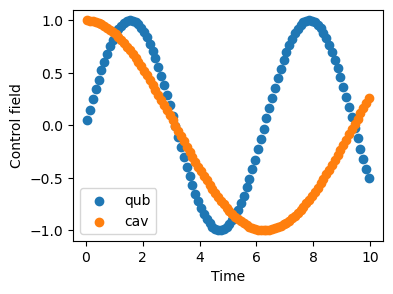

In [217]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.scatter(ts_mids, es_qub, label="qub");
ax.scatter(ts_mids, es_cav, label="cav");

ax.set_xlabel("Time");
ax.set_ylabel("Control field");

ax.legend();

In [218]:
drive = make_drive(N_cav, chi)

In [219]:
psi_init = tensor(basis(2), basis(N_cav, 0))
rho_init = ket2dm(psi_init)

In [220]:
rho_fin = drive(rho_init, es_qub, es_cav, dts)

## Solver with relaxation

In [222]:
t1_qub = 48.3
t2_qub = 33.0
t1_cav = 237.0

In [224]:
# dts must be the same
# dt_idle = dts[0]

In [225]:
def make_drive_with_relax(N_cav, chi, t1_qub, t2_qub, t1_cav, dt_idle):
    
    idle_after_drive_dt = make_idle(N_cav, t1_qub, t2_qub, t1_cav, dt_idle)
    
    def drive_with_relax(rho_init, es_qub, es_cav, dts):
        
        def f(rho, x):
            e_qub, e_cav, dt = x
            uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            rho = uevol @ rho @ hconj(uevol)
            rho = idle_after_drive_dt(rho)
            return rho, None
    
        rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
        
        return rho_fin
    
    return drive_with_relax

In [226]:
dt_idle = dts[0]

In [227]:
drive_with_relax = make_drive_with_relax(N_cav, chi, t1_qub, t2_qub, t1_cav, dt_idle)

In [194]:
rho_fin_with_relax = drive_with_relax(rho_init, es_qub, es_cav, dts)

## QuTiP check

In [228]:
def build_h_qt(N_cav, chi, es_qub, es_cav):
    a = qt.tensor(qt.identity(2), qt.destroy(N_cav))
    adag = a.dag()
    n_phot = adag * a
    sigz = qt.tensor(qt.sigmaz(), qt.identity(N_cav))
    sigp = qt.tensor(qt.sigmap(), qt.identity(N_cav))
    one = qt.tensor(qt.identity(2), qt.identity(N_cav))

    H_drift = +(chi / 2) * n_phot * (sigz + one)
    
    h = [
        H_drift,
        [mu_qub * sigp, es_qub],
        [mu_qub * sigp.dag(), es_qub.conj()],
        [mu_cav * adag, es_cav],
        [mu_cav * adag.dag(), es_cav.conj()],
    ]
    
    return h

In [229]:
ts_qt = np.array(ts)
es_qub_qt, es_cav_qt = make_es(ts_qt, module=np)

In [230]:
h_qt = build_h_qt(N_cav, chi, es_qub_qt, es_cav_qt)

In [231]:
psi_init_qt = qt.Qobj(psi_init, dims=[[2, N_cav], [1]])
rho_init_qt = qt.ket2dm(psi_init_qt)

In [232]:
def build_c_ops_qt(N_cav, t1_qub, t2_qub, t1_cav):
    get_t_phi_qub = lambda t1, t2: 1 / ((1 / t2) - (1 / t1) / 2)
    t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

    sigm = qt.tensor(qt.sigmam(), qt.identity(N_cav))
    sigz = qt.tensor(qt.sigmaz(), qt.identity(N_cav))
    a = qt.tensor(qt.identity(2), qt.destroy(N_cav))
    
    c_ops = [
        1 / np.sqrt(t1_qub) * sigm,
        1 / np.sqrt(t_phi_qub) * sigz / np.sqrt(2),
        1 / np.sqrt(t1_cav) * a
    ]
    return c_ops

In [233]:
c_ops_qt = build_c_ops_qt(N_cav, t1_qub, t2_qub, t1_cav)

In [234]:
res_qt = qt.mesolve(h_qt, rho_init_qt, ts_qt, c_ops_qt)

In [235]:
rho_fin_qt = res_qt.states[-1]

In [236]:
qt.fidelity(rho_fin_qt, qt.Qobj(np.array(rho_fin), dims=[[2, N_cav], [2, N_cav]]))

np.float64(0.9389371769447236)

In [237]:
qt.fidelity(rho_fin_qt, qt.Qobj(np.array(rho_fin_with_relax), dims=[[2, N_cav], [2, N_cav]]))

np.float64(0.9999952190486627)